### Stage 1: CPM Model Development — Weekdays & Weekends

This notebook develops CPM models for **both weekday** (Mon–Fri) **and weekend** (Sat–Sun) data to capture how the temperature–energy relationship differs between occupancy periods.

### Buildings Analyzed
- **KEPCO** — Korea Electric Power Corporation  
- **KEA** — Korea Energy Agency  

### Notebook Structure
1. Setup & shared CPM functions  
2. Data loading (weekday + weekend split)  
3. Overall scatter plots  
4. CPM model fitting — weekdays  
5. CPM model fitting — weekends  
6. Model fit visualizations  
7. Yearly individual CPM analysis — weekdays  
8. Yearly individual CPM analysis — weekends  
9. Individual building diagnostic reports  
10. Save parameters to CSV  
11. Weekday vs Weekend comparison

---

In [46]:
# ============================================================================
# SETUP AND IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, curve_fit, nnls
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Output folders
for path in [
    'CPM_Results/Weekdays',
    'CPM_Results/Weekends',
    'CPM_Results/Combined',
    'CPM_Results/Weekdays/Yearly_Individual',
    'CPM_Results/Weekends/Yearly_Individual',
]:
    os.makedirs(path, exist_ok=True)

for building in ['KEPCO', 'KEA']:
    os.makedirs(f'CPM_Results/Weekdays/{building}', exist_ok=True)
    os.makedirs(f'CPM_Results/Weekends/{building}', exist_ok=True)

print('Libraries imported successfully')
print('Output folders created')

Libraries imported successfully
Output folders created


In [47]:
# ============================================================================
# CPM MODEL FUNCTIONS AND FITTING
# ============================================================================

def cpm_model(temp, alpha, tau_h, tau_c, beta_h, beta_c):
    """
    5-parameter Change-Point Model.

    Parameters
    ----------
    temp   : array  — Outdoor temperature (°C)
    alpha  : float  — Base load (Wh/m²)
    tau_h  : float  — Heating change-point (°C)
    tau_c  : float  — Cooling change-point (°C)
    beta_h : float  — Heating slope (Wh/m²/°C)
    beta_c : float  — Cooling slope (Wh/m²/°C)
    """
    temp = np.asarray(temp)
    eui  = np.full_like(temp, alpha, dtype=float)
    eui[temp < tau_h] = alpha + beta_h * (tau_h - temp[temp < tau_h])
    eui[temp > tau_c] = alpha + beta_c * (temp[temp > tau_c] - tau_c)
    return eui


def fit_cpm_model(df, temp_col='temp_external', eui_col='EUI_Wh_m2'):
    """
    Two-stage CPM fitting:
      Stage 1 — differential_evolution locates tau_h and tau_c (global search,
                 no gradient needed for the non-smooth change-points).
      Stage 2 — curve_fit refines all 5 parameters starting from the DE result.
    """
    temp = df[temp_col].values
    eui  = df[eui_col].values

    # ── Stage 1: DE searches for the best tau_h / tau_c ──────────────────────
    # For fixed change-points the remaining 3 params (alpha, beta_h, beta_c)
    # reduce to a non-negative least-squares problem, making each DE evaluation
    # exact and fast.
    def _tau_objective(tau_params):
        tau_h, tau_c = tau_params
        if tau_h >= tau_c:
            return 1e10
        X = np.column_stack([
            np.ones(len(temp)),            # alpha
            np.maximum(tau_h - temp, 0),   # beta_h
            np.maximum(temp - tau_c, 0),   # beta_c
        ])
        coeffs, _ = nnls(X, eui)
        return float(np.sum((eui - X @ coeffs) ** 2))

    de_result = differential_evolution(
        _tau_objective,
        bounds  = [(5, 18), (19, 30)],
        seed    = 42,
        maxiter = 500,
        tol     = 1e-8,
        polish  = True,
    )
    tau_h0, tau_c0 = de_result.x

    # ── Stage 2: curve_fit — all 5 params, seeded from DE tau_h / tau_c ─────
    dead_mask = (temp >= tau_h0) & (temp <= tau_c0)
    alpha0    = float(eui[dead_mask].mean()) if dead_mask.any() else float(eui.mean())

    try:
        popt, _ = curve_fit(
            cpm_model, temp, eui,
            p0     = [alpha0, tau_h0, tau_c0, 0.3, 0.5],
            bounds = ([0,5, 19,  0,  0],
                      [eui.max() * 1.2, 18, 30, 50, 50]),
            maxfev = 10000,
        )
        alpha, tau_h, tau_c, beta_h, beta_c = popt
    except Exception:
        # Fallback: use NNLS coefficients from DE stage
        X = np.column_stack([
            np.ones(len(temp)),
            np.maximum(tau_h0 - temp, 0),
            np.maximum(temp - tau_c0, 0),
        ])
        coeffs, _ = nnls(X, eui)
        alpha, beta_h, beta_c = float(coeffs[0]), float(coeffs[1]), float(coeffs[2])
        tau_h, tau_c = tau_h0, tau_c0

    eui_pred = cpm_model(temp, alpha, tau_h, tau_c, beta_h, beta_c)
    ss_res   = float(np.sum((eui - eui_pred) ** 2))
    ss_tot   = float(np.sum((eui - eui.mean()) ** 2))
    rmse     = float(np.sqrt(np.mean((eui - eui_pred) ** 2)))

    params = dict(alpha=alpha, tau_h=tau_h, tau_c=tau_c, beta_h=beta_h, beta_c=beta_c)
    metrics = dict(
        R2        = 1 - ss_res / ss_tot,
        RMSE      = rmse,
        CV_RMSE   = rmse / eui.mean() * 100,
        n_samples = len(df),
    )
    return params, metrics


print('CPM functions defined (hybrid DE + curve_fit)')

CPM functions defined (hybrid DE + curve_fit)


In [48]:
# ============================================================================
# LOAD DATA — split into weekday and weekend datasets
# ============================================================================

data_folder = 'Prepared_Data'

kepco_all = pd.read_csv(f'{data_folder}/KEPCO_AllYears_Preprocessed_Method1.csv')
kea_all   = pd.read_csv(f'{data_folder}/Ali_KEA.csv')

datasets_weekday = {
    'KEPCO': kepco_all[kepco_all['is_weekend'] == 0].copy(),
    'KEA':   kea_all[kea_all['is_weekend'] == 0].copy(),
}

datasets_weekend = {
    'KEPCO': kepco_all[kepco_all['is_weekend'] == 1].copy(),
    'KEA':   kea_all[kea_all['is_weekend'] == 1].copy(),
}

totals = {'KEPCO': len(kepco_all), 'KEA': len(kea_all)}

print('Data Summary')
print('-' * 80)
print(f'{"Building":<10} {"Total":<8} {"Weekdays":<10} {"Weekends":<10} {"Temp Range":<22} {"EUI Range"}')
print('-' * 80)
for name in ['KEPCO', 'KEA']:
    wd = datasets_weekday[name]
    we = datasets_weekend[name]
    tr = f"{wd['temp_external'].min():.1f} to {wd['temp_external'].max():.1f}°C"
    er = f"{wd['EUI_Wh_m2'].min():.0f} – {wd['EUI_Wh_m2'].max():.0f}"
    print(f"{name:<10} {totals[name]:<8} {len(wd):<10} {len(we):<10} {tr:<22} {er}")
print('-' * 80)

Data Summary
--------------------------------------------------------------------------------
Building   Total    Weekdays   Weekends   Temp Range             EUI Range
--------------------------------------------------------------------------------
KEPCO      763      604        159        -10.4 to 32.7°C        6 – 20
KEA        774      539        235        -7.1 to 32.0°C         81 – 234
--------------------------------------------------------------------------------


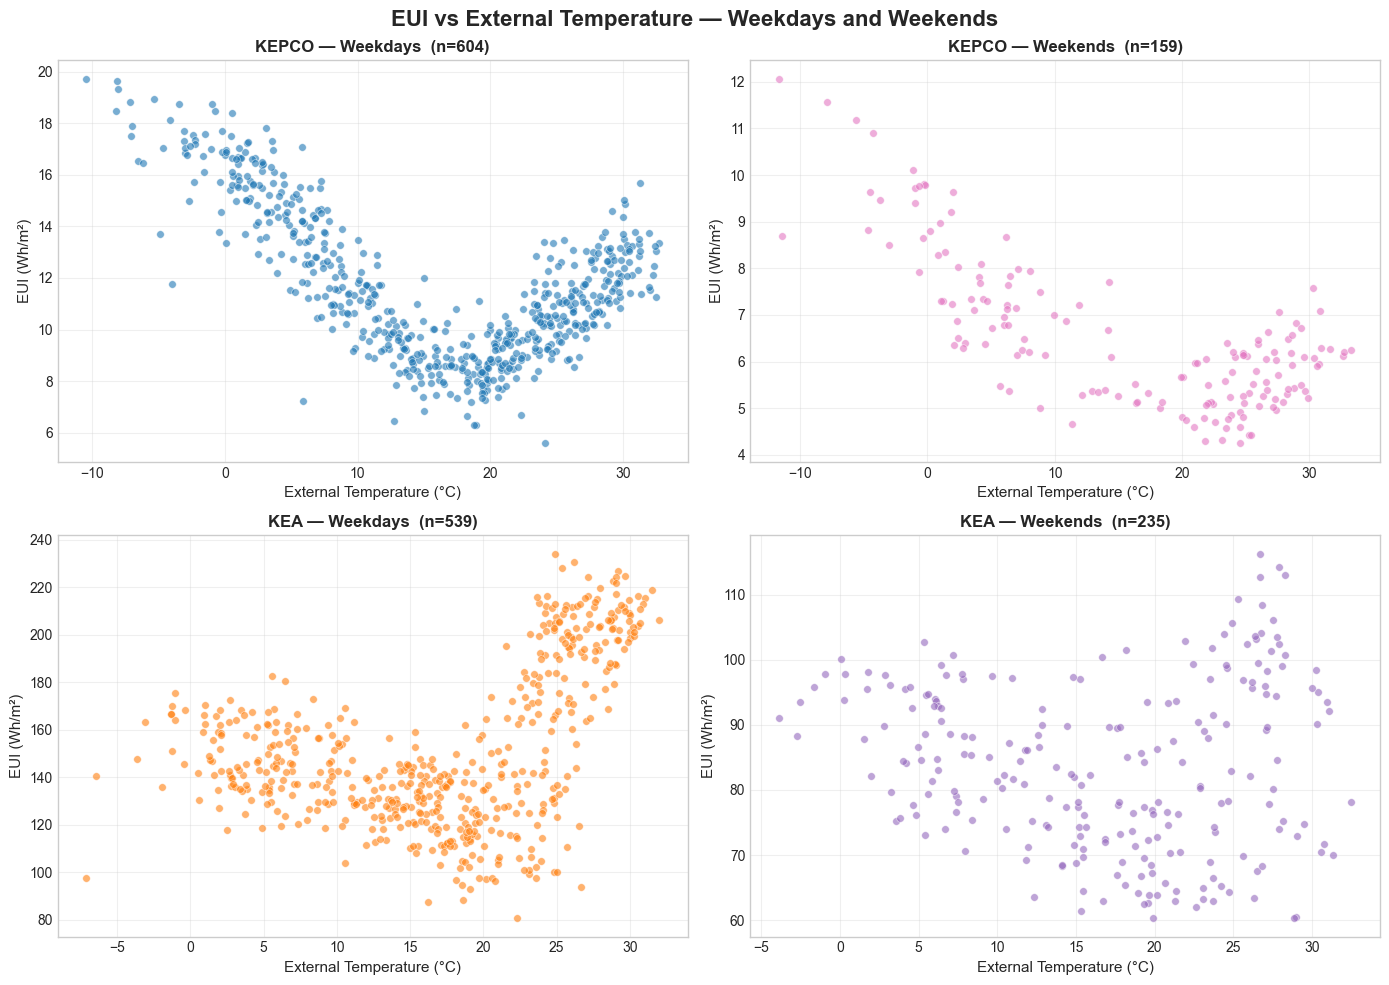

Saved: CPM_Results/Combined/00_EUI_vs_Temp_Weekday_Weekend.png


In [49]:
# ============================================================================
# SCATTER PLOTS — weekday vs weekend side-by-side for each building
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EUI vs External Temperature — Weekdays and Weekends',
             fontsize=16, fontweight='bold')

wd_colors = {'KEPCO': '#1f77b4', 'KEA': '#ff7f0e'}
we_colors = {'KEPCO': '#e377c2', 'KEA': '#9467bd'}

for col, (label, datasets, colors) in enumerate([
    ('Weekdays', datasets_weekday, wd_colors),
    ('Weekends', datasets_weekend, we_colors),
]):
    for row, name in enumerate(['KEPCO', 'KEA']):
        ax = axes[row, col]
        df = datasets[name]
        ax.scatter(df['temp_external'], df['EUI_Wh_m2'],
                   alpha=0.6, s=30, c=colors[name],
                   edgecolors='white', linewidth=0.5)
        ax.set_xlabel('External Temperature (°C)', fontsize=11)
        ax.set_ylabel('EUI (Wh/m²)', fontsize=11)
        ax.set_title(f'{name} — {label}  (n={len(df)})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CPM_Results/Combined/00_EUI_vs_Temp_Weekday_Weekend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: CPM_Results/Combined/00_EUI_vs_Temp_Weekday_Weekend.png')

In [50]:
# ============================================================================
# FIT CPM MODELS — WEEKDAYS
# ============================================================================

print('=' * 80)
print('FITTING CPM MODELS — WEEKDAYS')
print('=' * 80)

cpm_results_weekday = {}

for name, df in datasets_weekday.items():
    print(f'\n{"-"*40}  {name}')
    if df.empty:
        print('  (skipped: no weekday data)')
        continue
    params, metrics = fit_cpm_model(df)
    cpm_results_weekday[name] = dict(params=params, metrics=metrics, data=df)

    print(f'  α (Base Load)       = {params["alpha"]:.2f} Wh/m²')
    print(f'  τ_h (Heating CP)    = {params["tau_h"]:.2f} °C')
    print(f'  τ_c (Cooling CP)    = {params["tau_c"]:.2f} °C')
    print(f'  β_h (Heating Slope) = {params["beta_h"]:.4f} Wh/m²/°C')
    print(f'  β_c (Cooling Slope) = {params["beta_c"]:.4f} Wh/m²/°C')
    print(f'  R²      = {metrics["R2"]:.4f}')
    print(f'  RMSE    = {metrics["RMSE"]:.2f} Wh/m²')
    print(f'  CV-RMSE = {metrics["CV_RMSE"]:.2f}%')
    print(f'  n       = {metrics["n_samples"]}')

print('\n' + '=' * 80)
print('All weekday CPM models fitted')
print('=' * 80)

FITTING CPM MODELS — WEEKDAYS

----------------------------------------  KEPCO
  α (Base Load)       = 8.45 Wh/m²
  τ_h (Heating CP)    = 16.16 °C
  τ_c (Cooling CP)    = 19.41 °C
  β_h (Heating Slope) = 0.4714 Wh/m²/°C
  β_c (Cooling Slope) = 0.3747 Wh/m²/°C
  R²      = 0.8145
  RMSE    = 1.23 Wh/m²
  CV-RMSE = 10.55%
  n       = 604

----------------------------------------  KEA
  α (Base Load)       = 124.53 Wh/m²
  τ_h (Heating CP)    = 18.00 °C
  τ_c (Cooling CP)    = 19.73 °C
  β_h (Heating Slope) = 1.6206 Wh/m²/°C
  β_c (Cooling Slope) = 8.6291 Wh/m²/°C
  R²      = 0.5783
  RMSE    = 21.67 Wh/m²
  CV-RMSE = 14.30%
  n       = 539

All weekday CPM models fitted


In [51]:
# ============================================================================
# FIT CPM MODELS — WEEKENDS
# ============================================================================

print('=' * 80)
print('FITTING CPM MODELS — WEEKENDS')
print('=' * 80)

cpm_results_weekend = {}

for name, df in datasets_weekend.items():
    print(f'\n{"-"*40}  {name}')
    if df.empty:
        print('  (skipped: no weekend data)')
        continue
    params, metrics = fit_cpm_model(df)
    cpm_results_weekend[name] = dict(params=params, metrics=metrics, data=df)

    print(f'  α (Base Load)       = {params["alpha"]:.2f} Wh/m²')
    print(f'  τ_h (Heating CP)    = {params["tau_h"]:.2f} °C')
    print(f'  τ_c (Cooling CP)    = {params["tau_c"]:.2f} °C')
    print(f'  β_h (Heating Slope) = {params["beta_h"]:.4f} Wh/m²/°C')
    print(f'  β_c (Cooling Slope) = {params["beta_c"]:.4f} Wh/m²/°C')
    print(f'  R²      = {metrics["R2"]:.4f}')
    print(f'  RMSE    = {metrics["RMSE"]:.2f} Wh/m²')
    print(f'  CV-RMSE = {metrics["CV_RMSE"]:.2f}%')
    print(f'  n       = {metrics["n_samples"]}')

print('\n' + '=' * 80)
print('All weekend CPM models fitted')
print('=' * 80)

FITTING CPM MODELS — WEEKENDS

----------------------------------------  KEPCO
  α (Base Load)       = 5.37 Wh/m²
  τ_h (Heating CP)    = 13.13 °C
  τ_c (Cooling CP)    = 24.57 °C
  β_h (Heating Slope) = 0.2411 Wh/m²/°C
  β_c (Cooling Slope) = 0.1360 Wh/m²/°C
  R²      = 0.7417
  RMSE    = 0.80 Wh/m²
  CV-RMSE = 12.31%
  n       = 159

----------------------------------------  KEA
  α (Base Load)       = 76.91 Wh/m²
  τ_h (Heating CP)    = 15.68 °C
  τ_c (Cooling CP)    = 19.64 °C
  β_h (Heating Slope) = 1.0325 Wh/m²/°C
  β_c (Cooling Slope) = 1.4438 Wh/m²/°C
  R²      = 0.1701
  RMSE    = 11.65 Wh/m²
  CV-RMSE = 13.92%
  n       = 235

All weekend CPM models fitted


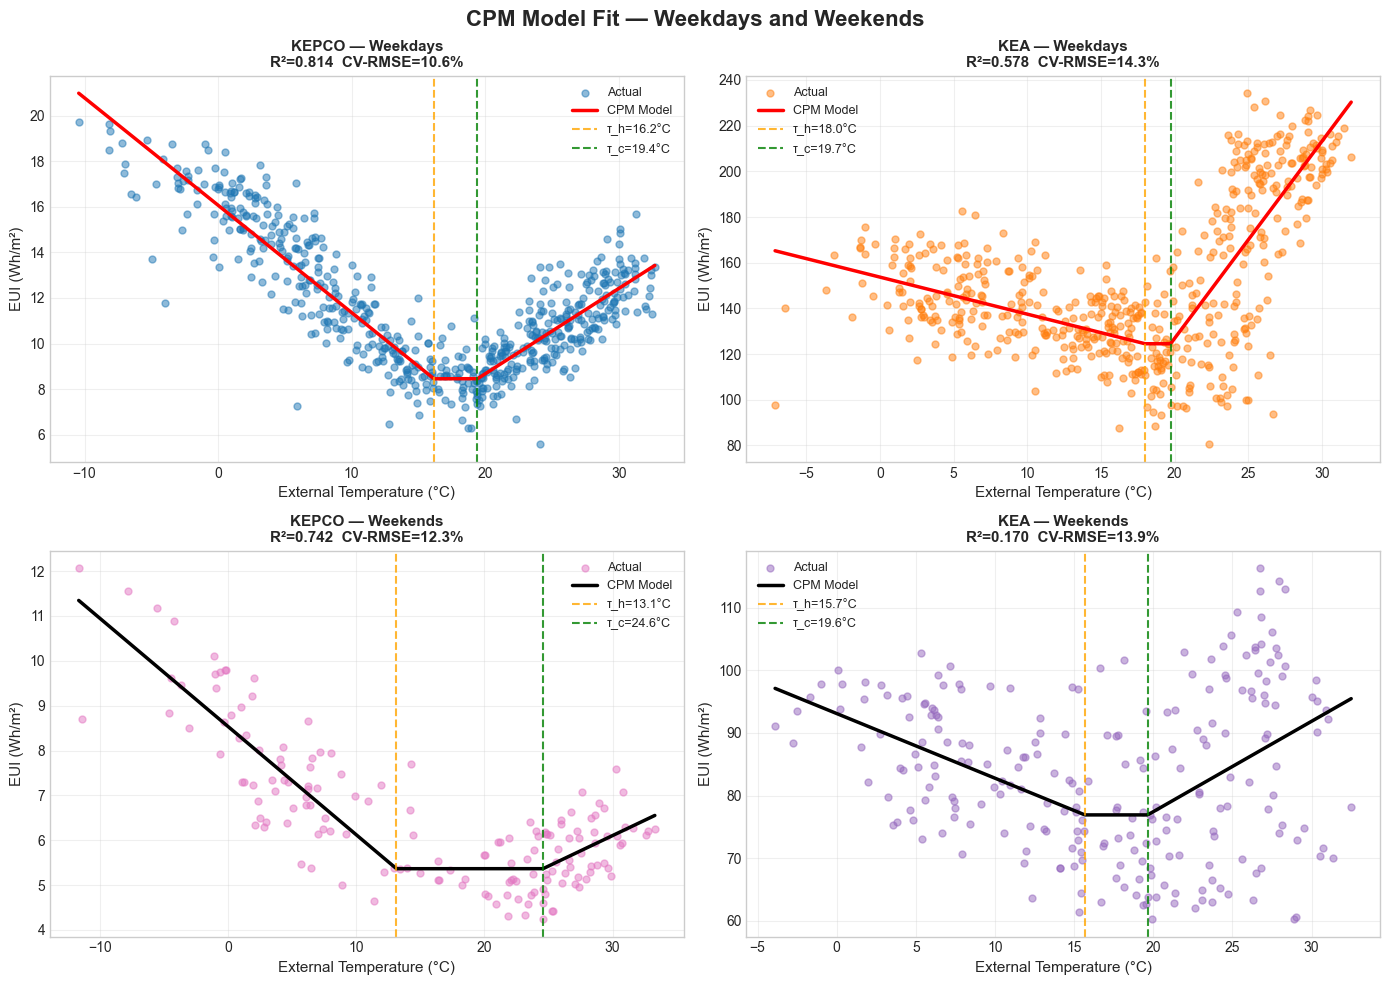

Saved: CPM_Results/Combined/01_CPM_Model_Fit_Weekday_Weekend.png


In [52]:
# ============================================================================
# MODEL FIT VISUALIZATIONS — weekday (row 0) and weekend (row 1)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CPM Model Fit — Weekdays and Weekends', fontsize=16, fontweight='bold')

for row, (label, results, scatter_colors, line_color) in enumerate([
    ('Weekdays', cpm_results_weekday, {'KEPCO': '#1f77b4', 'KEA': '#ff7f0e'}, 'r'),
    ('Weekends', cpm_results_weekend, {'KEPCO': '#e377c2', 'KEA': '#9467bd'}, 'k'),
]):
    for col, name in enumerate(['KEPCO', 'KEA']):
        ax = axes[row, col]
        res = results.get(name)
        if res is None:
            ax.set_visible(False)
            ax.set_title(f'{name} — {label}\n(no data)', fontsize=11)
            continue
        df, params, metrics = res['data'], res['params'], res['metrics']

        temp       = df['temp_external'].values
        eui_actual = df['EUI_Wh_m2'].values

        ax.scatter(temp, eui_actual, alpha=0.5, s=25,
                   c=scatter_colors[name], label='Actual')

        temp_range = np.linspace(temp.min(), temp.max(), 300)
        ax.plot(temp_range, cpm_model(temp_range, **params),
                color=line_color, linewidth=2.5, label='CPM Model')

        ax.axvline(params['tau_h'], color='orange', linestyle='--', alpha=0.8,
                   label=f'τ_h={params["tau_h"]:.1f}°C')
        ax.axvline(params['tau_c'], color='green',  linestyle='--', alpha=0.8,
                   label=f'τ_c={params["tau_c"]:.1f}°C')

        ax.set_xlabel('External Temperature (°C)', fontsize=11)
        ax.set_ylabel('EUI (Wh/m²)', fontsize=11)
        ax.set_title(
            f'{name} — {label}\nR²={metrics["R2"]:.3f}  CV-RMSE={metrics["CV_RMSE"]:.1f}%',
            fontsize=11, fontweight='bold'
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CPM_Results/Combined/01_CPM_Model_Fit_Weekday_Weekend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: CPM_Results/Combined/01_CPM_Model_Fit_Weekday_Weekend.png')

In [53]:
# ============================================================================
# YEARLY CPM ANALYSIS — WEEKDAYS
# ============================================================================

data_type = 'Weekdays'
yearly_output_wd = f'CPM_Results/{data_type}/Yearly_Individual'

print('=' * 80)
print(f'YEARLY CPM ANALYSIS — {data_type.upper()}')
print('=' * 80)

yearly_results_weekday = []

for building_name, df in datasets_weekday.items():
    print(f'\n{"="*60}  {building_name}')
    years = sorted(df['year'].unique())
    print(f'Years: {[int(y) for y in years]}')

    building_rows = []
    for year in years:
        df_year = df[df['year'] == year].copy()
        n = len(df_year)
        print(f'\n  {year}  ({n} days)', end='')

        params, metrics = fit_cpm_model(df_year)
        print(f'  R²={metrics["R2"]:.3f}  CV-RMSE={metrics["CV_RMSE"]:.1f}%')
        print(f'     α={params["alpha"]:.1f}  τ_h={params["tau_h"]:.1f}°C  '
              f'τ_c={params["tau_c"]:.1f}°C  '
              f'β_h={params["beta_h"]:.3f}  β_c={params["beta_c"]:.3f}')

        row = dict(Building=building_name, Year=int(year), Data_Type=data_type,
                   **params, **metrics)
        yearly_results_weekday.append(row)
        building_rows.append(row)

    if building_rows:
        out = f'{yearly_output_wd}/{building_name}_Yearly_Parameters.csv'
        pd.DataFrame(building_rows).to_csv(out, index=False)
        print(f'\n  Saved: {out}')

if yearly_results_weekday:
    out = f'{yearly_output_wd}/All_Buildings_Yearly_Parameters.csv'
    pd.DataFrame(yearly_results_weekday).to_csv(out, index=False)
    print(f'\nSaved combined: {out}')

print('\nWeekday yearly analysis complete')

YEARLY CPM ANALYSIS — WEEKDAYS

============================================================  KEPCO
Years: [2020, 2021, 2022, 2023, 2024, 2025]

  2020  (86 days)  R²=0.914  CV-RMSE=8.1%
     α=8.1  τ_h=15.7°C  τ_c=19.9°C  β_h=0.502  β_c=0.419

  2021  (112 days)  R²=0.905  CV-RMSE=7.6%
     α=8.1  τ_h=16.1°C  τ_c=19.3°C  β_h=0.473  β_c=0.264

  2022  (112 days)  R²=0.842  CV-RMSE=10.4%
     α=8.6  τ_h=15.6°C  τ_c=19.1°C  β_h=0.436  β_c=0.221

  2023  (114 days)  R²=0.750  CV-RMSE=10.1%
     α=8.6  τ_h=17.5°C  τ_c=19.0°C  β_h=0.452  β_c=0.429

  2024  (120 days)  R²=0.847  CV-RMSE=9.1%
     α=8.2  τ_h=18.0°C  τ_c=19.0°C  β_h=0.485  β_c=0.417

  2025  (60 days)  R²=0.737  CV-RMSE=11.3%
     α=9.2  τ_h=14.9°C  τ_c=19.0°C  β_h=0.447  β_c=0.289

  Saved: CPM_Results/Weekdays/Yearly_Individual/KEPCO_Yearly_Parameters.csv

============================================================  KEA
Years: [2022, 2023, 2024]

  2022  (208 days)  R²=0.622  CV-RMSE=11.6%
     α=134.7  τ_h=16.9°C  τ_c=19.0

Creating yearly EUI vs Temperature plots (Weekdays)...


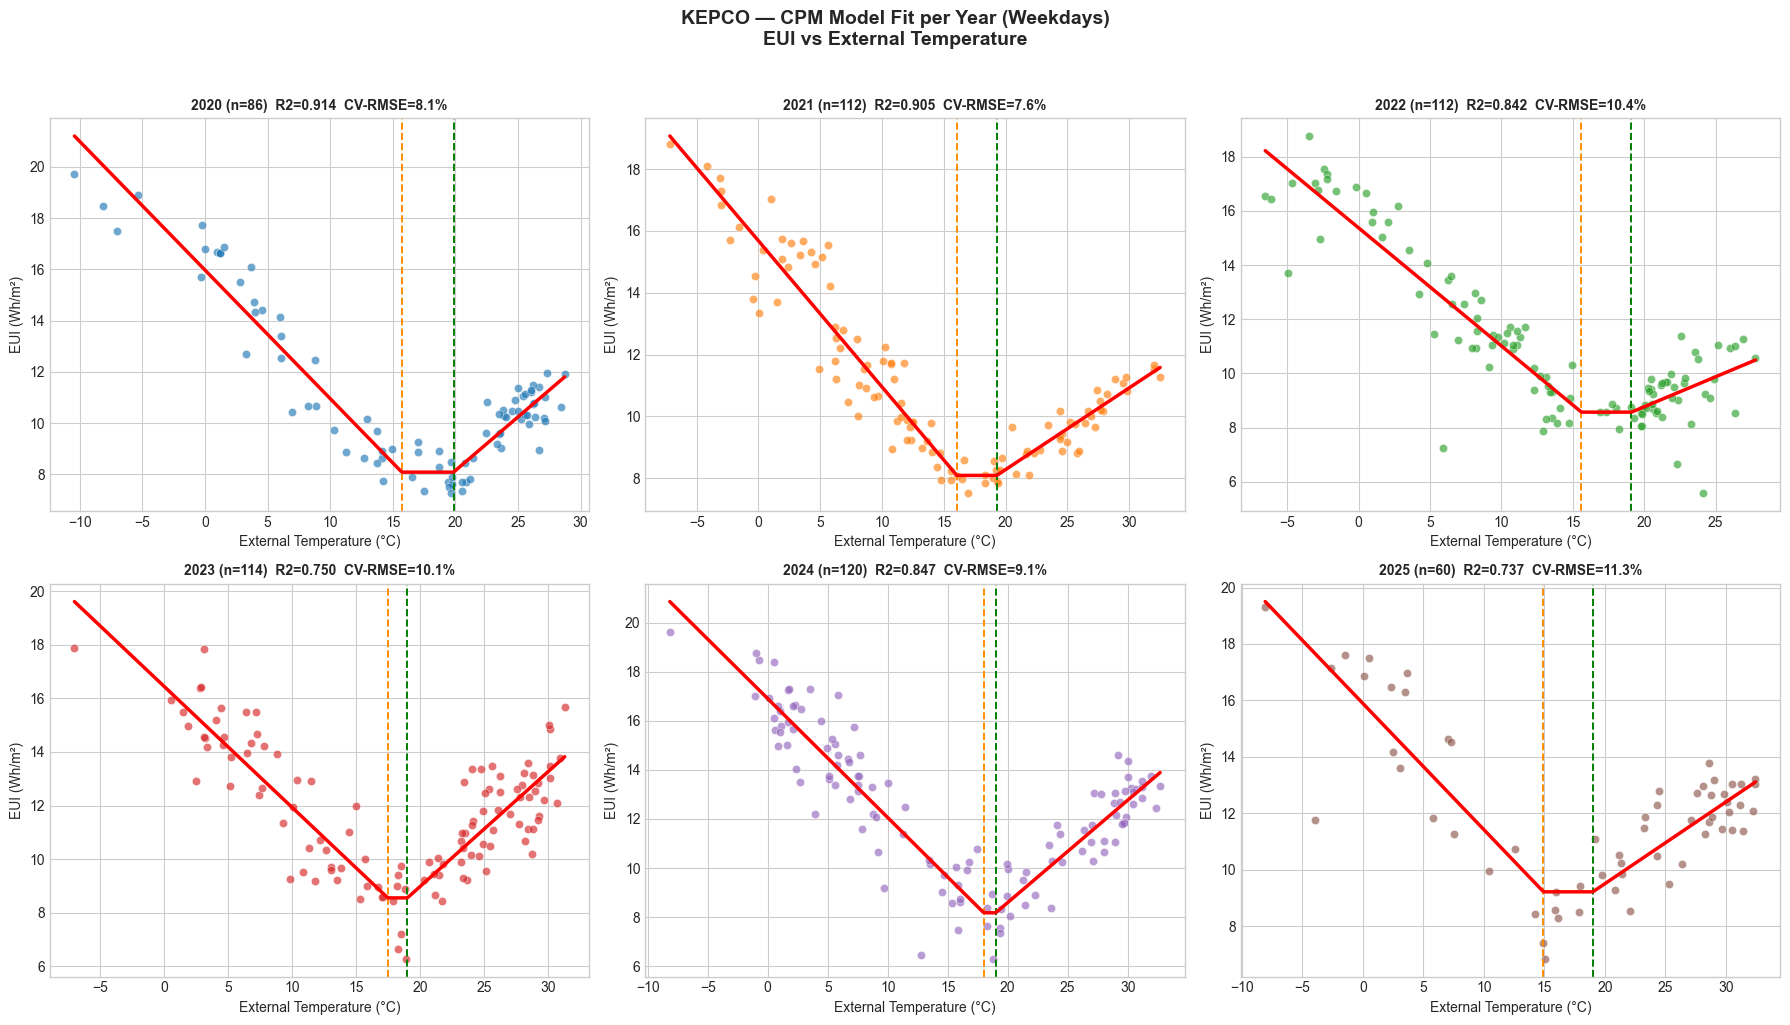

  Saved: CPM_Results/Weekdays/Yearly_Individual/KEPCO_Yearly_CPM_EUI_vs_Temp.png


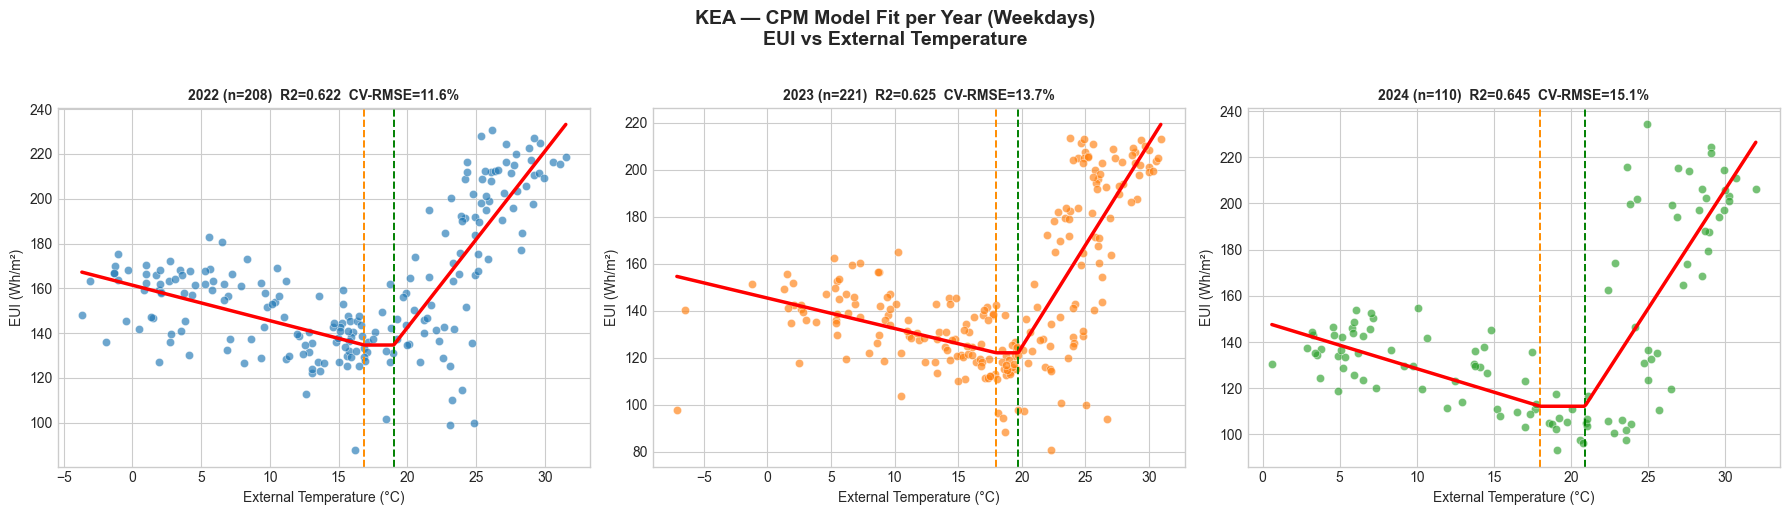

  Saved: CPM_Results/Weekdays/Yearly_Individual/KEA_Yearly_CPM_EUI_vs_Temp.png
Weekday yearly graphs done


In [54]:
# ============================================================================
# YEARLY VISUAL GRAPHS — WEEKDAYS
# ============================================================================

print(f'Creating yearly EUI vs Temperature plots (Weekdays)...')
year_palette = plt.cm.tab10.colors

for building_name, df in datasets_weekday.items():
    valid_years = sorted(df['year'].unique())
    if not valid_years:
        print(f'  No valid years for {building_name} — skipping')
        continue

    ncols = min(3, len(valid_years))
    nrows = (len(valid_years) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    fig.suptitle(f'{building_name} — CPM Model Fit per Year (Weekdays)\nEUI vs External Temperature',
                 fontsize=14, fontweight='bold', y=1.02)

    for i, year in enumerate(valid_years):
        ax  = axes_flat[i]
        yr  = next((r for r in yearly_results_weekday
                    if r['Building'] == building_name and r['Year'] == int(year)), None)
        if yr is None:
            ax.set_visible(False)
            continue

        params  = {k: yr[k] for k in ['alpha', 'tau_h', 'tau_c', 'beta_h', 'beta_c']}
        df_year = df[df['year'] == year]
        temp    = df_year['temp_external'].values
        eui     = df_year['EUI_Wh_m2'].values
        color   = year_palette[i % len(year_palette)]

        ax.scatter(temp, eui, alpha=0.65, s=35, color=color,
                   edgecolors='white', linewidth=0.4, label='Actual', zorder=2)
        t_rng = np.linspace(temp.min(), temp.max(), 300)
        ax.plot(t_rng, cpm_model(t_rng, **params), 'r-', linewidth=2.5,
                label='CPM fit', zorder=3)
        ax.axvline(params['tau_h'], color='darkorange', linestyle='--', linewidth=1.4,
                   label=f'τ_h={params["tau_h"]:.1f}°C')
        ax.axvline(params['tau_c'], color='green', linestyle='--', linewidth=1.4,
                   label=f'τ_c={params["tau_c"]:.1f}°C')

        ax.set_xlabel('External Temperature (°C)', fontsize=10)
        ax.set_ylabel('EUI (Wh/m²)', fontsize=10)
        ax.set_title(
            f'{int(year)} (n={yr["n_samples"]})  R2={yr["R2"]:.3f}  CV-RMSE={yr["CV_RMSE"]:.1f}%',
            fontsize=10, fontweight='bold')

    for j in range(len(valid_years), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    out = f'CPM_Results/Weekdays/Yearly_Individual/{building_name}_Yearly_CPM_EUI_vs_Temp.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

print('Weekday yearly graphs done')

In [55]:
# ============================================================================
# YEARLY CPM ANALYSIS — WEEKENDS
# ============================================================================

data_type = 'Weekends'
yearly_output_we = f'CPM_Results/{data_type}/Yearly_Individual'

print('=' * 80)
print(f'YEARLY CPM ANALYSIS — {data_type.upper()}')
print('=' * 80)

yearly_results_weekend = []

for building_name, df in datasets_weekend.items():
    print(f'\n{"="*60}  {building_name}')
    years = sorted(df['year'].unique())
    print(f'Years: {[int(y) for y in years]}')

    building_rows = []
    for year in years:
        df_year = df[df['year'] == year].copy()
        n = len(df_year)
        print(f'\n  {year}  ({n} days)', end='')

        params, metrics = fit_cpm_model(df_year)
        print(f'  R²={metrics["R2"]:.3f}  CV-RMSE={metrics["CV_RMSE"]:.1f}%')
        print(f'     α={params["alpha"]:.1f}  τ_h={params["tau_h"]:.1f}°C  '
              f'τ_c={params["tau_c"]:.1f}°C  '
              f'β_h={params["beta_h"]:.3f}  β_c={params["beta_c"]:.3f}')

        row = dict(Building=building_name, Year=int(year), Data_Type=data_type,
                   **params, **metrics)
        yearly_results_weekend.append(row)
        building_rows.append(row)

    if building_rows:
        out = f'{yearly_output_we}/{building_name}_Yearly_Parameters.csv'
        pd.DataFrame(building_rows).to_csv(out, index=False)
        print(f'\n  Saved: {out}')

if yearly_results_weekend:
    out = f'{yearly_output_we}/All_Buildings_Yearly_Parameters.csv'
    pd.DataFrame(yearly_results_weekend).to_csv(out, index=False)
    print(f'\nSaved combined: {out}')

print('\nWeekend yearly analysis complete')

YEARLY CPM ANALYSIS — WEEKENDS

============================================================  KEPCO
Years: [2020, 2021, 2022, 2023, 2024, 2025]

  2020  (24 days)  R²=0.745  CV-RMSE=9.2%
     α=5.0  τ_h=18.0°C  τ_c=23.4°C  β_h=0.163  β_c=0.070

  2021  (46 days)  R²=0.793  CV-RMSE=13.2%
     α=4.9  τ_h=17.6°C  τ_c=24.6°C  β_h=0.205  β_c=0.171

  2022  (29 days)  R²=0.761  CV-RMSE=10.5%
     α=5.4  τ_h=8.0°C  τ_c=19.0°C  β_h=0.416  β_c=0.108

  2023  (20 days)  R²=0.737  CV-RMSE=8.5%
     α=5.7  τ_h=18.0°C  τ_c=30.0°C  β_h=0.131  β_c=1.491

  2024  (29 days)  R²=0.826  CV-RMSE=9.2%
     α=5.5  τ_h=9.1°C  τ_c=19.0°C  β_h=0.370  β_c=0.053

  2025  (11 days)  R²=0.871  CV-RMSE=7.5%
     α=5.8  τ_h=14.9°C  τ_c=22.5°C  β_h=0.259  β_c=0.070

  Saved: CPM_Results/Weekends/Yearly_Individual/KEPCO_Yearly_Parameters.csv

============================================================  KEA
Years: [2022, 2023, 2024]

  2022  (85 days)  R²=0.496  CV-RMSE=12.0%
     α=75.8  τ_h=12.4°C  τ_c=20.2°C  β_h=1

Creating yearly EUI vs Temperature plots (Weekends)...


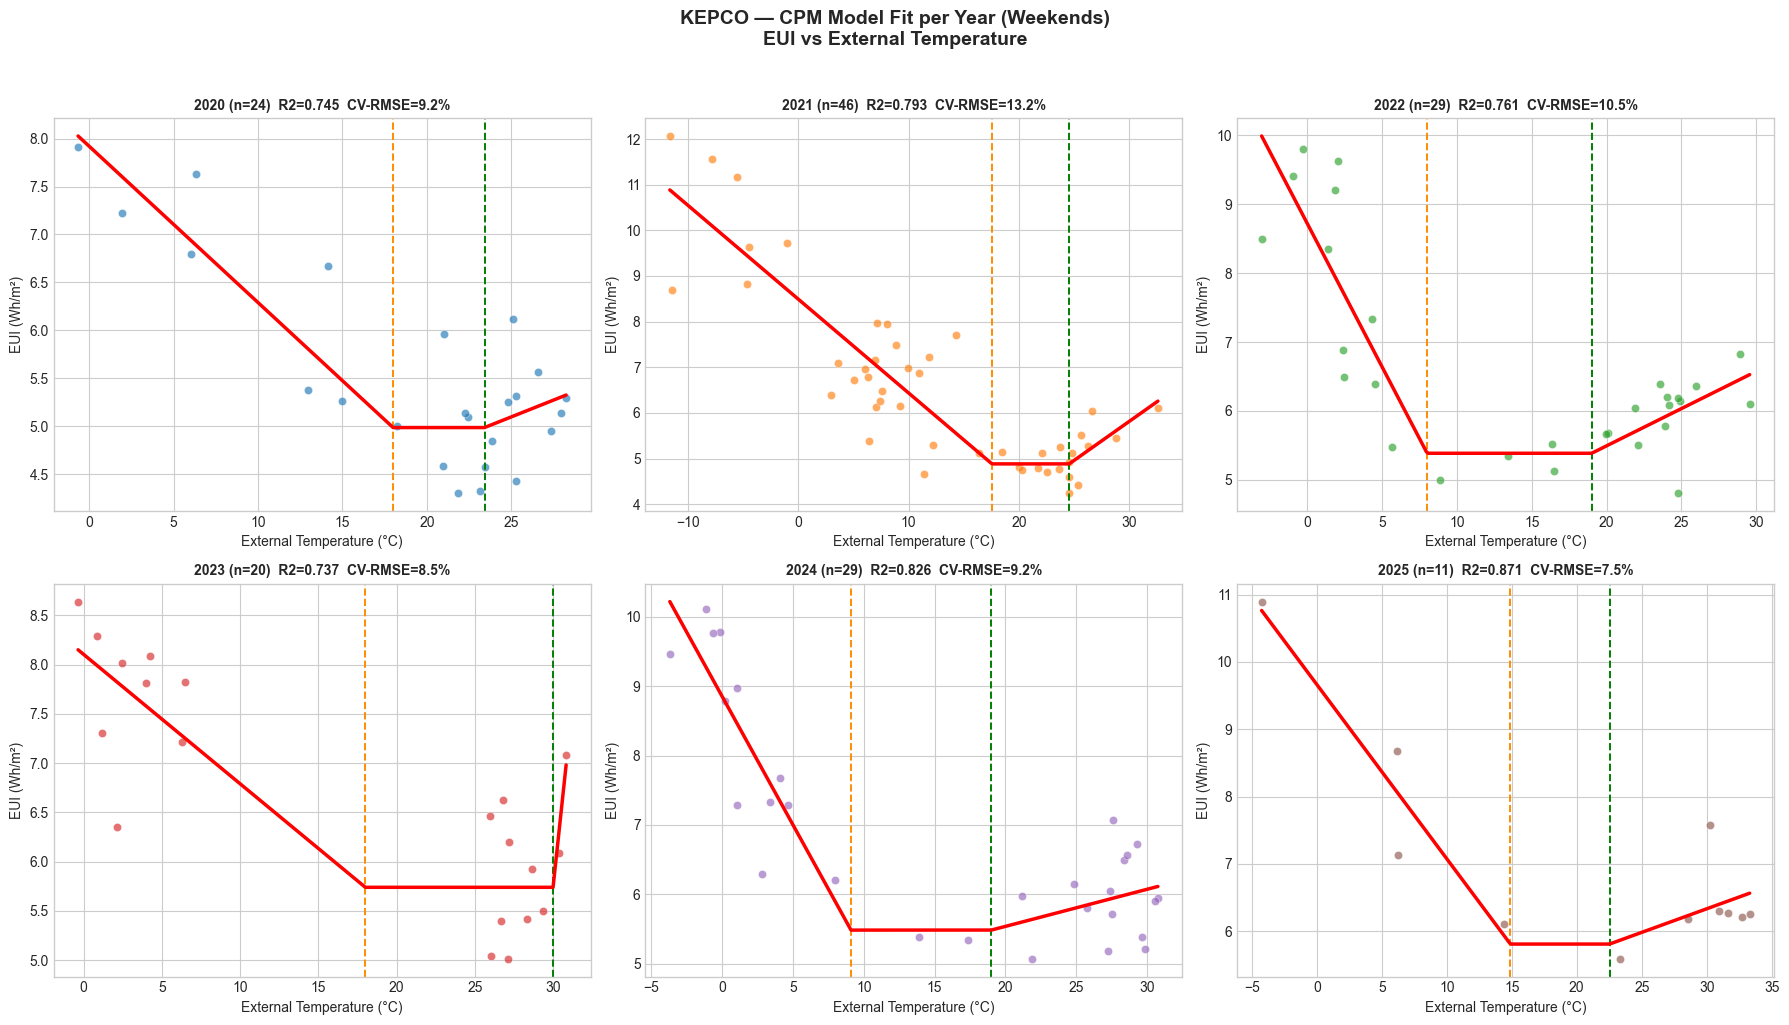

  Saved: CPM_Results/Weekends/Yearly_Individual/KEPCO_Yearly_CPM_EUI_vs_Temp.png


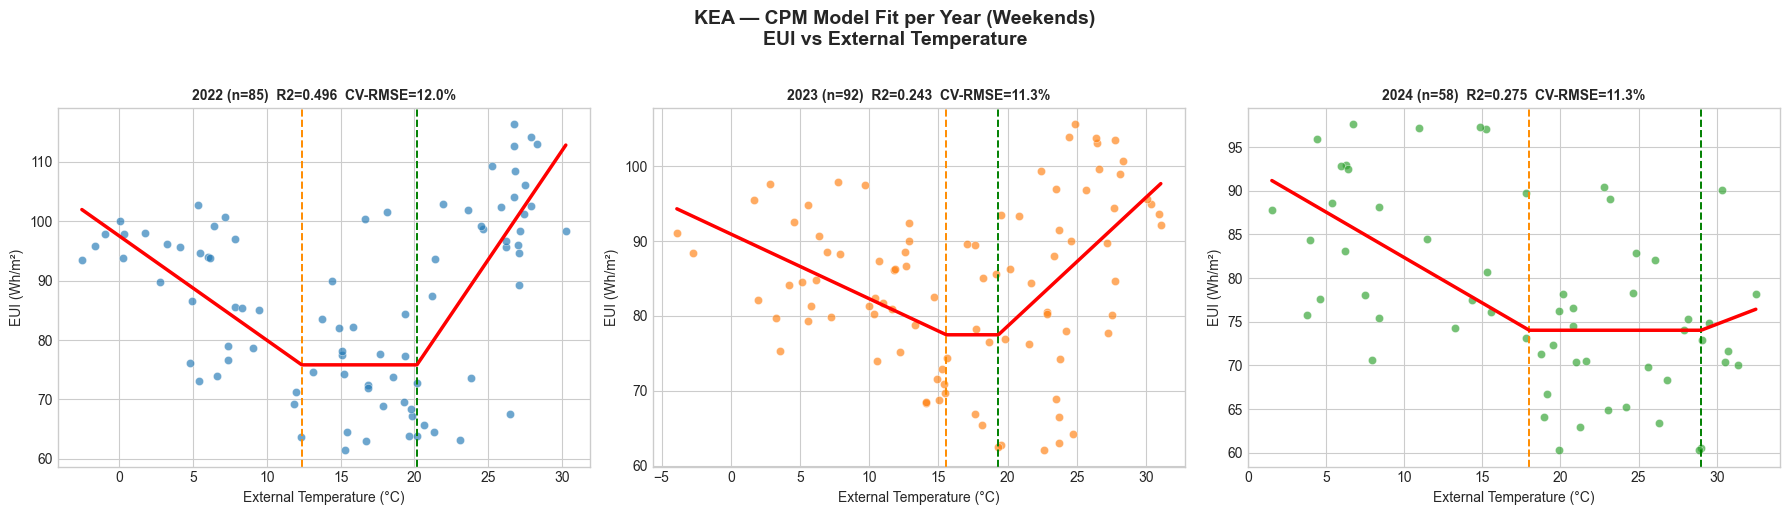

  Saved: CPM_Results/Weekends/Yearly_Individual/KEA_Yearly_CPM_EUI_vs_Temp.png
Weekend yearly graphs done


In [56]:
# ============================================================================
# YEARLY VISUAL GRAPHS — WEEKENDS
# ============================================================================

print('Creating yearly EUI vs Temperature plots (Weekends)...')
year_palette = plt.cm.tab10.colors

for building_name, df in datasets_weekend.items():
    valid_years = sorted(df['year'].unique())
    if not valid_years:
        print(f'  No valid years for {building_name} — skipping')
        continue

    ncols = min(3, len(valid_years))
    nrows = (len(valid_years) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    fig.suptitle(f'{building_name} — CPM Model Fit per Year (Weekends)\nEUI vs External Temperature',
                 fontsize=14, fontweight='bold', y=1.02)

    for i, year in enumerate(valid_years):
        ax  = axes_flat[i]
        yr  = next((r for r in yearly_results_weekend
                    if r['Building'] == building_name and r['Year'] == int(year)), None)
        if yr is None:
            ax.set_visible(False)
            continue

        params  = {k: yr[k] for k in ['alpha', 'tau_h', 'tau_c', 'beta_h', 'beta_c']}
        df_year = df[df['year'] == year]
        temp    = df_year['temp_external'].values
        eui     = df_year['EUI_Wh_m2'].values
        color   = year_palette[i % len(year_palette)]

        ax.scatter(temp, eui, alpha=0.65, s=35, color=color,
                   edgecolors='white', linewidth=0.4, label='Actual', zorder=2)
        t_rng = np.linspace(temp.min(), temp.max(), 300)
        ax.plot(t_rng, cpm_model(t_rng, **params), 'r-', linewidth=2.5,
                label='CPM fit', zorder=3)
        ax.axvline(params['tau_h'], color='darkorange', linestyle='--', linewidth=1.4,
                   label=f'τ_h={params["tau_h"]:.1f}°C')
        ax.axvline(params['tau_c'], color='green', linestyle='--', linewidth=1.4,
                   label=f'τ_c={params["tau_c"]:.1f}°C')

        ax.set_xlabel('External Temperature (°C)', fontsize=10)
        ax.set_ylabel('EUI (Wh/m²)', fontsize=10)
        ax.set_title(
            f'{int(year)} (n={yr["n_samples"]})  R2={yr["R2"]:.3f}  CV-RMSE={yr["CV_RMSE"]:.1f}%',
            fontsize=10, fontweight='bold')

    for j in range(len(valid_years), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    out = f'CPM_Results/Weekends/Yearly_Individual/{building_name}_Yearly_CPM_EUI_vs_Temp.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

print('Weekend yearly graphs done')

In [57]:
# ============================================================================
# INDIVIDUAL BUILDING DIAGNOSTIC REPORTS — WEEKDAYS
# ============================================================================

print('Creating weekday building diagnostic reports...')

for name, res in cpm_results_weekday.items():
    df, params, metrics = res['data'], res['params'], res['metrics']
    temp       = df['temp_external'].values
    eui_actual = df['EUI_Wh_m2'].values
    eui_pred   = cpm_model(temp, **params)
    residuals  = eui_actual - eui_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{name} — CPM Diagnostic Report (Weekdays)', fontsize=15, fontweight='bold')

    # 1: Model fit
    ax = axes[0, 0]
    ax.scatter(temp, eui_actual, alpha=0.5, s=20, c='steelblue', label='Actual')
    t_rng = np.linspace(temp.min(), temp.max(), 300)
    ax.plot(t_rng, cpm_model(t_rng, **params), 'r-', linewidth=2.5, label='CPM Model')
    ax.axvline(params['tau_h'], color='orange', linestyle='--', alpha=0.7)
    ax.axvline(params['tau_c'], color='green',  linestyle='--', alpha=0.7)
    ax.set_xlabel('External Temperature (°C)')
    ax.set_ylabel('EUI (Wh/m²)')
    ax.set_title('Temperature vs EUI with CPM Model')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2: Actual vs Predicted
    ax = axes[0, 1]
    ax.scatter(eui_actual, eui_pred, alpha=0.5, s=20, c='steelblue')
    lo, hi = min(eui_actual.min(), eui_pred.min()), max(eui_actual.max(), eui_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect Fit')
    ax.set_xlabel('Actual EUI (Wh/m²)')
    ax.set_ylabel('Predicted EUI (Wh/m²)')
    ax.set_title(f'Actual vs Predicted  (R²={metrics["R2"]:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3: Residuals vs Temperature
    ax = axes[1, 0]
    ax.scatter(temp, residuals, alpha=0.5, s=20, c='steelblue')
    ax.axhline(0,                       color='red',    linestyle='-',  linewidth=2)
    ax.axhline( 2 * residuals.std(), color='orange', linestyle='--', alpha=0.7)
    ax.axhline(-2 * residuals.std(), color='orange', linestyle='--', alpha=0.7)
    ax.set_xlabel('External Temperature (°C)')
    ax.set_ylabel('Residual (Wh/m²)')
    ax.set_title('Residuals vs Temperature')
    ax.grid(True, alpha=0.3)

    # 4: Residual distribution
    ax = axes[1, 1]
    ax.hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    mu, std = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x, np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi)),
            'r-', linewidth=2, label=f'Normal (μ={mu:.1f}, σ={std:.1f})')
    ax.set_xlabel('Residual (Wh/m²)')
    ax.set_ylabel('Density')
    ax.set_title('Residual Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = f'CPM_Results/Weekdays/{name}/{name}_Weekday_CPM_Report.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved: {out}')

print('Weekday building reports done')

Creating weekday building diagnostic reports...
  Saved: CPM_Results/Weekdays/KEPCO/KEPCO_Weekday_CPM_Report.png
  Saved: CPM_Results/Weekdays/KEA/KEA_Weekday_CPM_Report.png
Weekday building reports done


In [58]:
# ============================================================================
# INDIVIDUAL BUILDING DIAGNOSTIC REPORTS — WEEKENDS
# ============================================================================

print('Creating weekend building diagnostic reports...')

for name, res in cpm_results_weekend.items():
    df, params, metrics = res['data'], res['params'], res['metrics']
    temp       = df['temp_external'].values
    eui_actual = df['EUI_Wh_m2'].values
    eui_pred   = cpm_model(temp, **params)
    residuals  = eui_actual - eui_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{name} — CPM Diagnostic Report (Weekends)', fontsize=15, fontweight='bold')

    # 1: Model fit
    ax = axes[0, 0]
    ax.scatter(temp, eui_actual, alpha=0.6, s=30, c='purple', label='Actual')
    t_rng = np.linspace(temp.min(), temp.max(), 300)
    ax.plot(t_rng, cpm_model(t_rng, **params), 'k-', linewidth=2.5, label='CPM Model')
    ax.axvline(params['tau_h'], color='orange', linestyle='--', alpha=0.7)
    ax.axvline(params['tau_c'], color='green',  linestyle='--', alpha=0.7)
    ax.set_xlabel('External Temperature (°C)')
    ax.set_ylabel('EUI (Wh/m²)')
    ax.set_title('Temperature vs EUI with CPM Model')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2: Actual vs Predicted
    ax = axes[0, 1]
    ax.scatter(eui_actual, eui_pred, alpha=0.6, s=30, c='purple')
    lo, hi = min(eui_actual.min(), eui_pred.min()), max(eui_actual.max(), eui_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect Fit')
    ax.set_xlabel('Actual EUI (Wh/m²)')
    ax.set_ylabel('Predicted EUI (Wh/m²)')
    ax.set_title(f'Actual vs Predicted  (R²={metrics["R2"]:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3: Residuals vs Temperature
    ax = axes[1, 0]
    ax.scatter(temp, residuals, alpha=0.6, s=30, c='purple')
    ax.axhline(0,                       color='red',    linestyle='-',  linewidth=2)
    ax.axhline( 2 * residuals.std(), color='orange', linestyle='--', alpha=0.7)
    ax.axhline(-2 * residuals.std(), color='orange', linestyle='--', alpha=0.7)
    ax.set_xlabel('External Temperature (°C)')
    ax.set_ylabel('Residual (Wh/m²)')
    ax.set_title('Residuals vs Temperature')
    ax.grid(True, alpha=0.3)

    # 4: Residual distribution
    ax = axes[1, 1]
    ax.hist(residuals, bins=20, color='purple', edgecolor='white', alpha=0.7, density=True)
    mu, std = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x, np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi)),
            'r-', linewidth=2, label=f'Normal (μ={mu:.1f}, σ={std:.1f})')
    ax.set_xlabel('Residual (Wh/m²)')
    ax.set_ylabel('Density')
    ax.set_title('Residual Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = f'CPM_Results/Weekends/{name}/{name}_Weekend_CPM_Report.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved: {out}')

print('Weekend building reports done')

Creating weekend building diagnostic reports...
  Saved: CPM_Results/Weekends/KEPCO/KEPCO_Weekend_CPM_Report.png
  Saved: CPM_Results/Weekends/KEA/KEA_Weekend_CPM_Report.png
Weekend building reports done


In [59]:
# ============================================================================
# SAVE CPM PARAMETERS TO CSV
# ============================================================================

def make_params_df(results_dict, data_type_label):
    rows = []
    for name, res in results_dict.items():
        p, m = res['params'], res['metrics']
        rows.append({
            'Building':              name,
            'Data_Type':             data_type_label,
            'Alpha_BaseLoad_Wh_m2':  p['alpha'],
            'Tau_h_HeatingCP_C':     p['tau_h'],
            'Tau_c_CoolingCP_C':     p['tau_c'],
            'Beta_h_HeatingSlope':   p['beta_h'],
            'Beta_c_CoolingSlope':   p['beta_c'],
            'R2':                    m['R2'],
            'RMSE_Wh_m2':            m['RMSE'],
            'CV_RMSE_percent':       m['CV_RMSE'],
            'N_Samples':             m['n_samples'],
        })
    return pd.DataFrame(rows)


df_wd = make_params_df(cpm_results_weekday, 'Weekday')
df_we = make_params_df(cpm_results_weekend, 'Weekend')
df_all = pd.concat([df_wd, df_we], ignore_index=True)

df_wd.to_csv('CPM_Results/Weekdays/CPM_Parameters_Weekday.csv',  index=False)
df_we.to_csv('CPM_Results/Weekends/CPM_Parameters_Weekend.csv',  index=False)
df_all.to_csv('CPM_Results/Combined/CPM_Parameters_All.csv',     index=False)

print('CPM Parameters saved to:')
print('  CPM_Results/Weekdays/CPM_Parameters_Weekday.csv')
print('  CPM_Results/Weekends/CPM_Parameters_Weekend.csv')
print('  CPM_Results/Combined/CPM_Parameters_All.csv')
print()
print(df_all.to_string(index=False))

CPM Parameters saved to:
  CPM_Results/Weekdays/CPM_Parameters_Weekday.csv
  CPM_Results/Weekends/CPM_Parameters_Weekend.csv
  CPM_Results/Combined/CPM_Parameters_All.csv

Building Data_Type  Alpha_BaseLoad_Wh_m2  Tau_h_HeatingCP_C  Tau_c_CoolingCP_C  Beta_h_HeatingSlope  Beta_c_CoolingSlope       R2  RMSE_Wh_m2  CV_RMSE_percent  N_Samples
   KEPCO   Weekday              8.451572          16.160696          19.413325             0.471417             0.374725 0.814457    1.226758        10.551474        604
     KEA   Weekday            124.531390          17.999412          19.728585             1.620636             8.629108 0.578306   21.665081        14.302928        539
   KEPCO   Weekend              5.365401          13.128947          24.569292             0.241096             0.136026 0.741698    0.802431        12.305112        159
     KEA   Weekend             76.907569          15.676309          19.642857             1.032466             1.443760 0.170130   11.649818       

WEEKDAY vs WEEKEND COMPARISON

KEPCO
  Parameter                       Weekday     Weekend     Δ (We−Wd)
  ------------------------------------------------------------------
  α (Base Load, Wh/m²)              8.452       5.365        -3.086
  τ_h (Heating CP, °C)             16.161      13.129        -3.032
  τ_c (Cooling CP, °C)             19.413      24.569        +5.156
  β_h (Heating Slope)               0.471       0.241        -0.230
  β_c (Cooling Slope)               0.375       0.136        -0.239
  R²                                0.814       0.742        -0.073
  CV-RMSE (%)                      10.551      12.305        +1.754

KEA
  Parameter                       Weekday     Weekend     Δ (We−Wd)
  ------------------------------------------------------------------
  α (Base Load, Wh/m²)            124.531      76.908       -47.624
  τ_h (Heating CP, °C)             17.999      15.676        -2.323
  τ_c (Cooling CP, °C)             19.729      19.643        -0.086
  β_

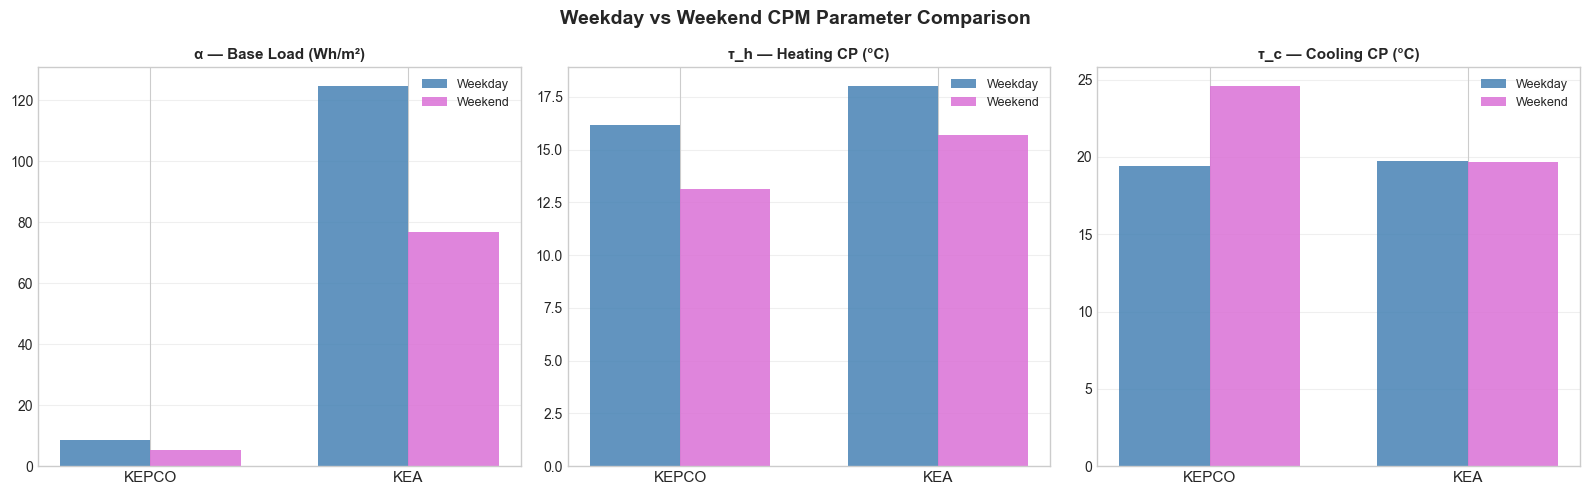


Saved: CPM_Results/Combined/02_Weekday_vs_Weekend_Parameter_Comparison.png

Key Insights:
  Lower α on weekends → reduced occupancy / equipment loads
  Different τ_h, τ_c  → HVAC setback schedules in effect
  Compare R² and CV-RMSE to assess where the model fits better


In [60]:
# ============================================================================
# WEEKDAY vs WEEKEND COMPARISON
# ============================================================================

print('=' * 80)
print('WEEKDAY vs WEEKEND COMPARISON')
print('=' * 80)

compare_params = [
    ('Alpha_BaseLoad_Wh_m2', 'α (Base Load, Wh/m²)'),
    ('Tau_h_HeatingCP_C',    'τ_h (Heating CP, °C)'),
    ('Tau_c_CoolingCP_C',    'τ_c (Cooling CP, °C)'),
    ('Beta_h_HeatingSlope',  'β_h (Heating Slope)'),
    ('Beta_c_CoolingSlope',  'β_c (Cooling Slope)'),
    ('R2',                   'R²'),
    ('CV_RMSE_percent',      'CV-RMSE (%)'),
]

for building in ['KEPCO', 'KEA']:
    wd_rows = df_wd[df_wd['Building'] == building]
    we_rows = df_we[df_we['Building'] == building]
    if wd_rows.empty or we_rows.empty:
        print(f'\n{building}: skipped (no weekend data)')
        continue
    wd = wd_rows.iloc[0]
    we = we_rows.iloc[0]

    print(f'\n{building}')
    print(f'  {"Parameter":<28} {"Weekday":>10}  {"Weekend":>10}  {"Δ (We−Wd)":>12}')
    print(f'  {"-"*66}')
    for col, label in compare_params:
        diff = we[col] - wd[col]
        print(f'  {label:<28} {wd[col]:>10.3f}  {we[col]:>10.3f}  {diff:>+12.3f}')

# ------ Visual comparison bar chart ------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Weekday vs Weekend CPM Parameter Comparison',
             fontsize=14, fontweight='bold')

buildings = [b for b in cpm_results_weekday if b in cpm_results_weekend]
x         = np.arange(len(buildings))
w         = 0.35

for ax, (col, label) in zip(axes, [
    ('Alpha_BaseLoad_Wh_m2', 'α — Base Load (Wh/m²)'),
    ('Tau_h_HeatingCP_C',    'τ_h — Heating CP (°C)'),
    ('Tau_c_CoolingCP_C',    'τ_c — Cooling CP (°C)'),
]):
    wd_vals = [df_wd[df_wd['Building'] == b][col].values[0] for b in buildings]
    we_vals = [df_we[df_we['Building'] == b][col].values[0] for b in buildings]

    ax.bar(x - w/2, wd_vals, w, label='Weekday', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, we_vals, w, label='Weekend', color='orchid',    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(buildings, fontsize=11)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('CPM_Results/Combined/02_Weekday_vs_Weekend_Parameter_Comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: CPM_Results/Combined/02_Weekday_vs_Weekend_Parameter_Comparison.png')

print('\nKey Insights:')
print('  Lower α on weekends → reduced occupancy / equipment loads')
print('  Different τ_h, τ_c  → HVAC setback schedules in effect')
print('  Compare R² and CV-RMSE to assess where the model fits better')